# BodyShapeGPT — Keyword ↔ Beta Parameter Correlation Analysis

This notebook finds which descriptive words correlate most strongly with each of the 10 SMPL shape parameters (betas), and derives normalized weight scores to guide training.

## 1. Import Libraries & Load Dataset

In [1]:
import json
import ast
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Load dataset ──────────────────────────────────────────────────────────────
# Run from repo root, or adjust the path below
DATASET_PATH = "../BodyShapeGPT_dataset.jsonl"

data = []
with open(DATASET_PATH) as f:
    for line in f:
        data.append(json.loads(line))

descriptions = [d["description"] for d in data]
betas = np.array([ast.literal_eval(d["shape_params"]) for d in data])  # (N, 10)

beta_cols = [f"beta_{i}" for i in range(10)]
df_betas = pd.DataFrame(betas, columns=beta_cols)

print(f"Samples : {len(data)}")
print(f"Beta shape: {betas.shape}")
df_betas.describe().round(3)

Samples : 21000
Beta shape: (21000, 10)


,beta_0,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6,beta_7,beta_8,beta_9
count,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000,21000.000
mean,0.005,0.007,-0.002,0.006,-0.019,-0.011,0.010,0.005,-0.004,0.008
std,1.393,1.399,1.413,1.413,1.405,1.406,1.399,1.400,1.403,1.406
min,-5.519,-5.572,-5.866,-4.983,-6.025,-5.310,-5.776,-6.049,-5.122,-5.219
25%,-0.938,-0.929,-0.940,-0.946,-0.965,-0.950,-0.923,-0.931,-0.949,-0.934
50%,-0.005,0.020,-0.010,0.003,-0.009,-0.010,0.009,0.004,-0.002,-0.016
75%,0.948,0.962,0.946,0.947,0.922,0.936,0.944,0.942,0.942,0.952
max,5.753,5.705,5.459,5.795,6.810,5.529,5.846,5.547,5.728,5.408


## 2. Beta Parameter Statistics & Distributions

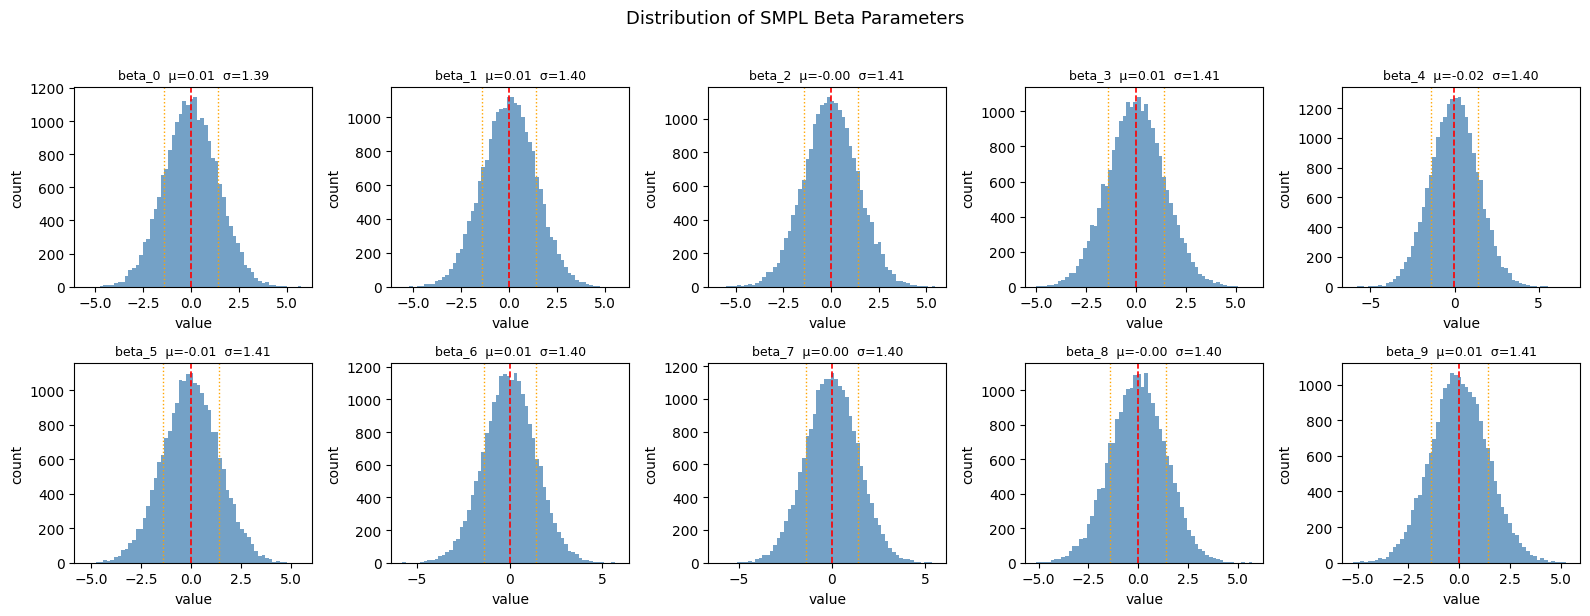

,mean,std
beta_0,0.005,1.393
beta_1,0.007,1.399
beta_2,-0.002,1.413
beta_3,0.006,1.413
beta_4,-0.019,1.405
beta_5,-0.011,1.406
beta_6,0.010,1.399
beta_7,0.005,1.400
beta_8,-0.004,1.403
beta_9,0.008,1.406


In [2]:
means = betas.mean(axis=0)
stds  = betas.std(axis=0)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()
for i in range(10):
    ax = axes[i]
    ax.hist(betas[:, i], bins=60, color="steelblue", alpha=0.75, edgecolor="none")
    ax.axvline(means[i], color="red",    linestyle="--", linewidth=1.2, label=f"μ={means[i]:.2f}")
    ax.axvline(means[i] + stds[i], color="orange", linestyle=":", linewidth=1)
    ax.axvline(means[i] - stds[i], color="orange", linestyle=":", linewidth=1, label=f"σ={stds[i]:.2f}")
    ax.set_title(f"beta_{i}  μ={means[i]:.2f}  σ={stds[i]:.2f}", fontsize=9)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.suptitle("Distribution of SMPL Beta Parameters", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
pd.DataFrame({"mean": means, "std": stds}, index=beta_cols).round(3)

## 3. Keyword Presence Matrix

Define keywords grouped by body region, build a binary presence matrix, and filter out rare terms.

In [3]:
KEYWORDS = {
    # ── Height ─────────────────────────────────────────────────────────────
    "height": ["tall", "short", "average height", "petite", "compact", "towering"],

    # ── Neck ───────────────────────────────────────────────────────────────
    "neck": ["tall neck", "short neck", "long neck", "slender neck"],

    # ── Arms ───────────────────────────────────────────────────────────────
    "arms_length": ["long arms", "short arms"],
    "arms_thickness": ["thick arms", "thin arms", "spindly arms", "sturdy arms", "robust arms"],

    # ── Legs ───────────────────────────────────────────────────────────────
    "legs_length": ["long legs", "short legs"],
    "legs_thickness": ["thick legs", "thin legs", "sturdy legs", "slender legs"],

    # ── Shoulders ──────────────────────────────────────────────────────────
    "shoulders": ["broad shoulders", "narrow shoulders", "wide shoulders"],

    # ── Hips ───────────────────────────────────────────────────────────────
    # NOTE: dataset uses "broad hip" / "narrow hip" — NOT "wide hips"
    "hips": ["broad hip", "narrow hip", "expansive hips", "slim hips"],

    # ── Body Mass ──────────────────────────────────────────────────────────
    "body_mass": ["lot of body mass", "low body mass", "meager body mass",
                  "ample body mass", "muscular", "slender"],

    # ── Bust & Waist Thickness ─────────────────────────────────────────────
    "bust": ["thick bust", "thin bust", "ample chest", "slim torso"],
    "waist": ["thick waist", "thin waist", "expansive waist", "slim waist"],
}

# Flat list, preserving group ordering
all_keywords = [kw for group in KEYWORDS.values() for kw in group]

# ── Binary presence matrix ─────────────────────────────────────────────────
MIN_COUNT = 20

presence_dict = {}
for kw in all_keywords:
    vec = np.array([1.0 if kw.lower() in d.lower() else 0.0 for d in descriptions])
    if vec.sum() >= MIN_COUNT:
        presence_dict[kw] = vec

kept_keywords = list(presence_dict.keys())
presence_matrix = np.stack([presence_dict[kw] for kw in kept_keywords], axis=1)  # (N, K)

# Frequency table
freq = pd.Series({kw: int(presence_dict[kw].sum()) for kw in kept_keywords}, name="count")
freq_df = freq.reset_index().rename(columns={"index": "keyword"}).sort_values("count", ascending=False)
print(f"Keywords kept (count ≥ {MIN_COUNT}): {len(kept_keywords)}")
freq_df.style.bar(subset=["count"], color="#5fba7d")

Keywords kept (count ≥ 20): 44


,keyword,count
2,average height,7417
1,short,6946
0,tall,4413
35,slender,2977
23,broad shoulders,2801
26,broad hip,2668
19,thick legs,2642
17,long legs,2632
18,short legs,2626
13,thin arms,2615


## 4. Pearson Correlation Analysis (Keyword vs Beta)

Compute point-biserial r and p-value for every (keyword, beta) pair. Significant = p < 0.05.

In [4]:
records = []
for kw in kept_keywords:
    vec = presence_dict[kw]
    for b_idx in range(10):
        r, p = stats.pointbiserialr(vec, betas[:, b_idx])
        records.append({
            "keyword":     kw,
            "beta_index":  b_idx,
            "beta":        f"beta_{b_idx}",
            "r":           round(r, 5),
            "p_value":     round(p, 6),
            "abs_r":       round(abs(r), 5),
            "significant": p < 0.05,
        })

corr_df = pd.DataFrame(records)

# Pivot table: keywords × betas
r_pivot = corr_df.pivot(index="keyword", columns="beta", values="r").round(4)

print(f"Total (keyword, beta) pairs: {len(corr_df)}")
print(f"Significant (p<0.05): {corr_df['significant'].sum()}")
corr_df.head(20)

Total (keyword, beta) pairs: 440
Significant (p<0.05): 291


,keyword,beta_index,beta,r,p_value,abs_r,significant
0,tall,0,beta_0,0.49349,0.000000,0.49349,True
1,tall,1,beta_1,0.03012,0.000013,0.03012,True
2,tall,2,beta_2,0.04597,0.000000,0.04597,True
3,tall,3,beta_3,-0.01394,0.043302,0.01394,True
4,tall,4,beta_4,0.05104,0.000000,0.05104,True
5,tall,5,beta_5,0.04330,0.000000,0.04330,True
6,tall,6,beta_6,-0.01431,0.038085,0.01431,True
7,tall,7,beta_7,-0.03097,0.000007,0.03097,True
8,tall,8,beta_8,-0.01846,0.007455,0.01846,True
9,tall,9,beta_9,0.01618,0.019072,0.01618,True


## 5. Correlation Heatmap Visualization

Two heatmaps: (a) all correlations, (b) significant-only (non-significant cells are blanked).

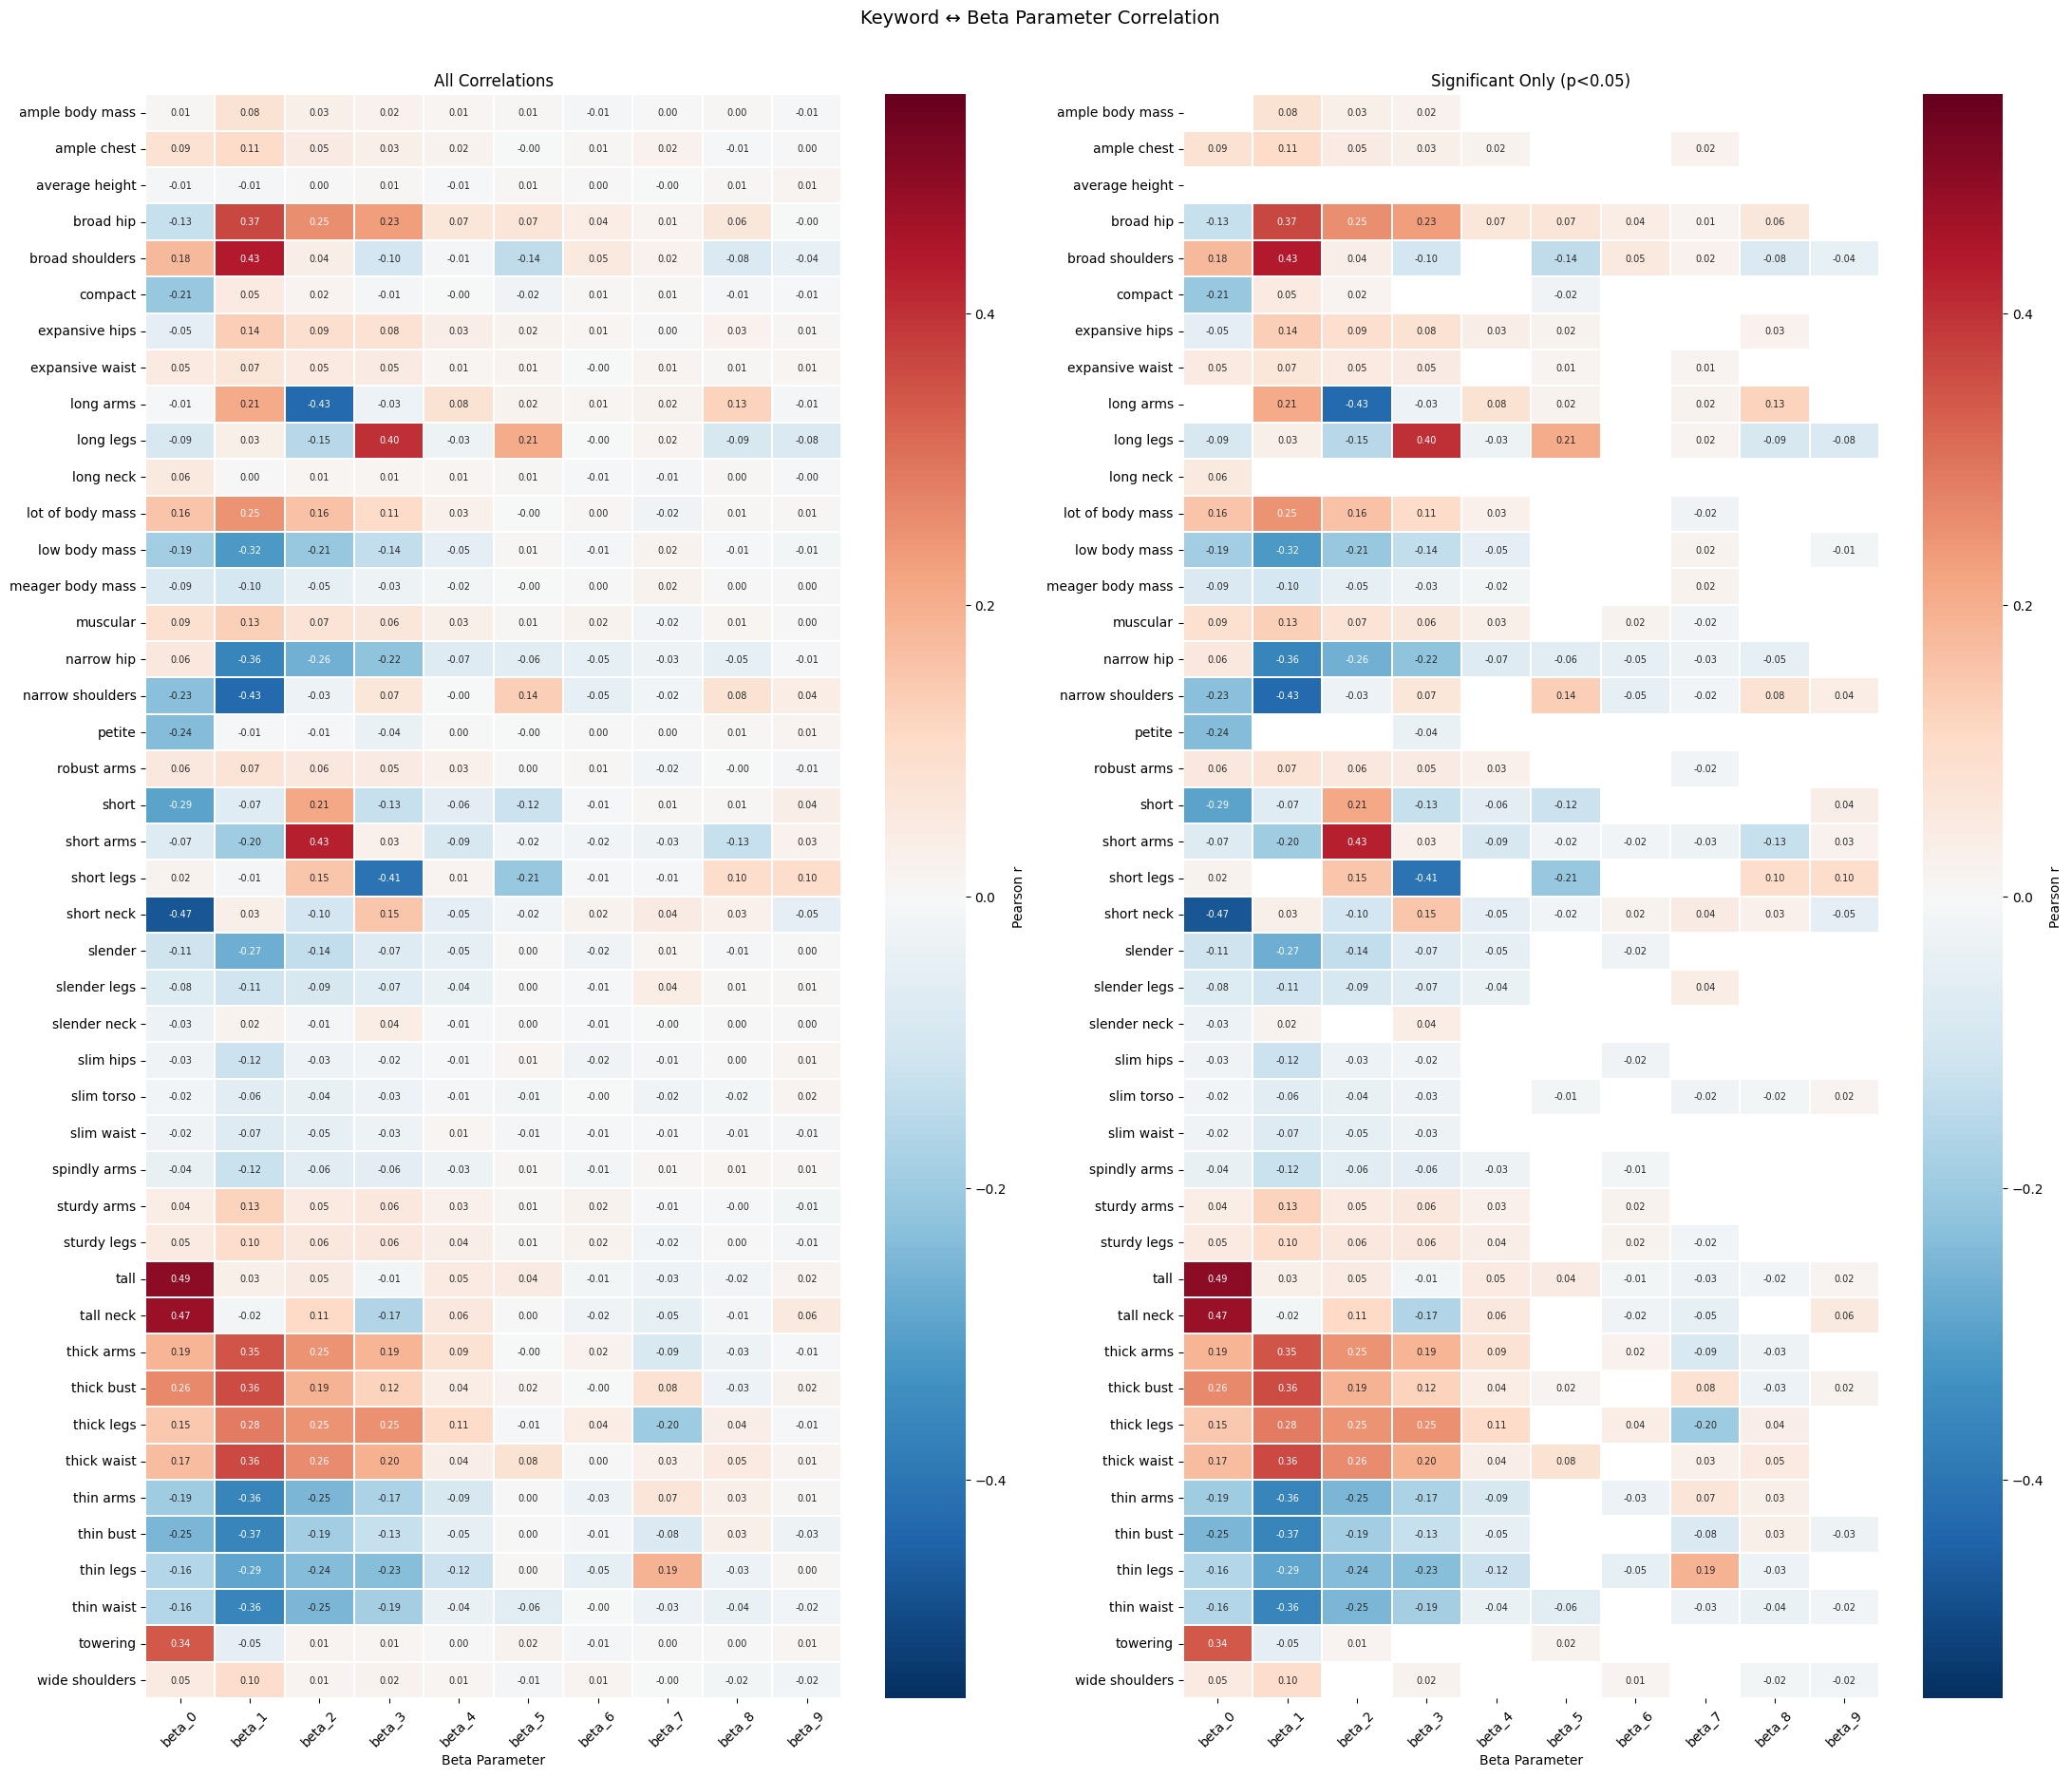

In [5]:
p_pivot = corr_df.pivot(index="keyword", columns="beta", values="p_value")

# Reorder columns
ordered_cols = [f"beta_{i}" for i in range(10)]
r_mat = r_pivot[ordered_cols]
p_mat = p_pivot[ordered_cols]

fig, axes = plt.subplots(1, 2, figsize=(22, max(8, len(kept_keywords) * 0.42)))

for ax, (title, mat, mask) in zip(axes, [
    ("All Correlations",        r_mat, None),
    ("Significant Only (p<0.05)", r_mat, p_mat >= 0.05),
]):
    sns.heatmap(
        mat,
        mask=mask,
        cmap="RdBu_r",
        center=0,
        vmin=-0.55, vmax=0.55,
        annot=True, fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.3,
        ax=ax,
        cbar_kws={"label": "Pearson r"},
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Beta Parameter")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Keyword ↔ Beta Parameter Correlation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Top Keywords per Beta Parameter

For each beta, show the 5 most positively and 5 most negatively correlated keywords.

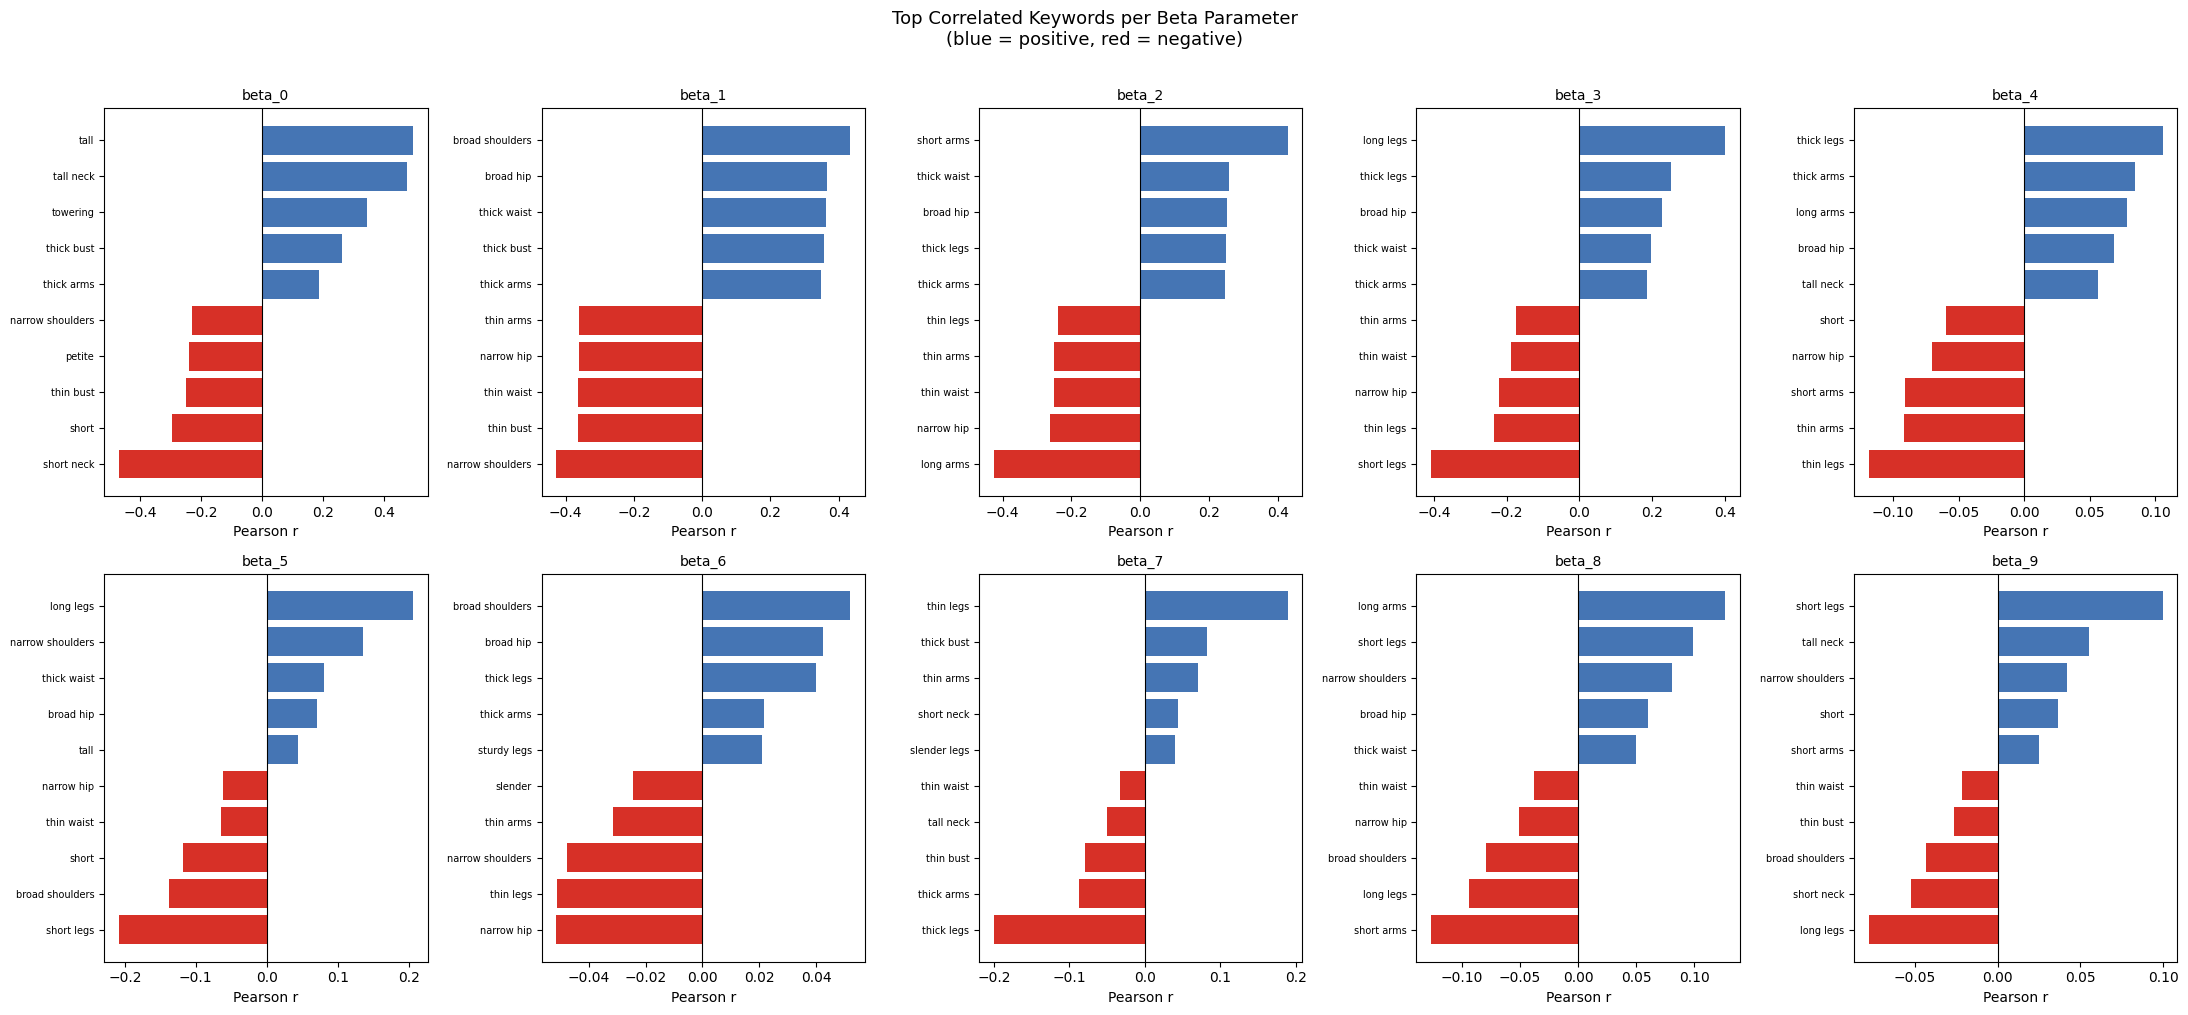

In [6]:
TOP_N = 5
sig_df = corr_df[corr_df["significant"]]

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for b_idx in range(10):
    ax = axes[b_idx]
    sub = sig_df[sig_df["beta_index"] == b_idx].sort_values("r")

    top_pos = sub.nlargest(TOP_N, "r")
    top_neg = sub.nsmallest(TOP_N, "r")
    plot_df = pd.concat([top_neg, top_pos]).drop_duplicates("keyword")
    plot_df = plot_df.sort_values("r")

    colors = ["#d73027" if r < 0 else "#4575b4" for r in plot_df["r"]]
    ax.barh(plot_df["keyword"], plot_df["r"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"beta_{b_idx}", fontsize=10)
    ax.set_xlabel("Pearson r")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Top Correlated Keywords per Beta Parameter\n(blue = positive, red = negative)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# Tabular view: best single keyword per beta (highest |r|, significant)
print("=== Best keyword per beta (highest |r|, p < 0.05) ===\n")
summary_rows = []
for b_idx in range(10):
    sub = sig_df[sig_df["beta_index"] == b_idx]
    if sub.empty:
        summary_rows.append({"beta": f"beta_{b_idx}", "best_keyword": "—", "r": np.nan})
        continue
    best = sub.loc[sub["abs_r"].idxmax()]
    summary_rows.append({"beta": f"beta_{b_idx}", "best_keyword": best["keyword"], "r": best["r"]})

pd.DataFrame(summary_rows).set_index("beta")

=== Best keyword per beta (highest |r|, p < 0.05) ===



,best_keyword,r
beta,,
beta_0,tall,0.49349
beta_1,broad shoulders,0.43425
beta_2,short arms,0.42935
beta_3,short legs,-0.40720
beta_4,thin legs,-0.11864
beta_5,short legs,-0.20847
beta_6,broad shoulders,0.05196
beta_7,thick legs,-0.20013
beta_8,long arms,0.12680


## 6b. Single Best Correlation Value per Beta

For training, pick **one r value per beta** — the keyword with the highest absolute Pearson r that is also statistically significant (p < 0.05).

In [8]:
# For each beta, find the single keyword with the highest |r| (significant only)
best_per_beta = []
for b_idx in range(10):
    sub = sig_df[sig_df["beta_index"] == b_idx]
    if sub.empty:
        best_per_beta.append({
            "beta": f"beta_{b_idx}",
            "best_keyword": "—",
            "r": 0.0,
            "abs_r": 0.0,
            "p_value": 1.0,
            "learnability": "❌ No signal",
        })
        continue
    row = sub.loc[sub["abs_r"].idxmax()]
    abs_r = row["abs_r"]
    if abs_r >= 0.40:
        label = "✅ Strong"
    elif abs_r >= 0.20:
        label = "🟡 Moderate"
    elif abs_r >= 0.10:
        label = "🟠 Weak"
    else:
        label = "❌ Very weak"
    best_per_beta.append({
        "beta": f"beta_{b_idx}",
        "best_keyword": row["keyword"],
        "r": row["r"],
        "abs_r": abs_r,
        "p_value": row["p_value"],
        "learnability": label,
    })

best_df = pd.DataFrame(best_per_beta).set_index("beta")
best_df

,best_keyword,r,abs_r,p_value,learnability
beta,,,,,
beta_0,tall,0.49349,0.49349,0.0,✅ Strong
beta_1,broad shoulders,0.43425,0.43425,0.0,✅ Strong
beta_2,short arms,0.42935,0.42935,0.0,✅ Strong
beta_3,short legs,-0.40720,0.40720,0.0,✅ Strong
beta_4,thin legs,-0.11864,0.11864,0.0,🟠 Weak
beta_5,short legs,-0.20847,0.20847,0.0,🟡 Moderate
beta_6,broad shoulders,0.05196,0.05196,0.0,❌ Very weak
beta_7,thick legs,-0.20013,0.20013,0.0,🟡 Moderate
beta_8,long arms,0.12680,0.12680,0.0,🟠 Weak


/tmp/ipykernel_380774/742198540.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380774/742198540.py:33: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380774/742198540.py:33: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_380774/742198540.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from fon

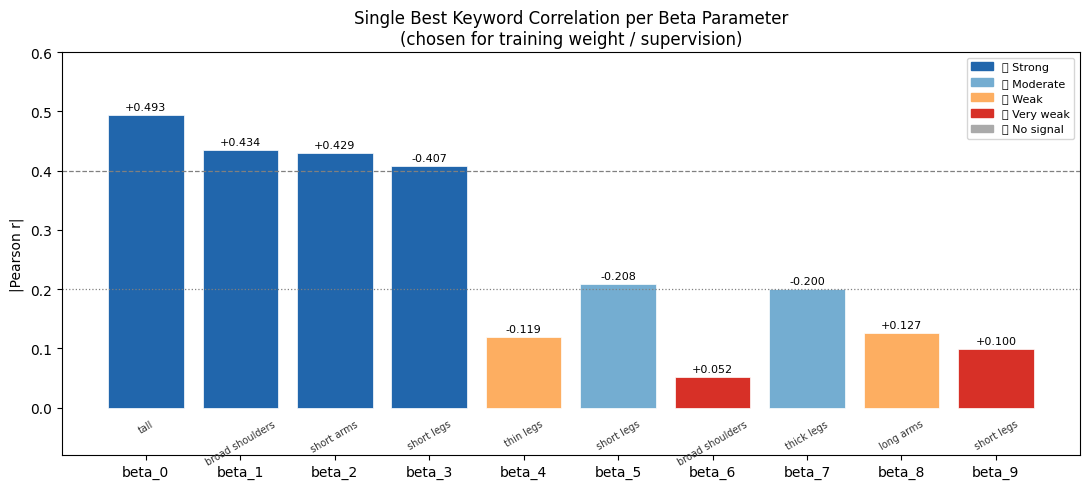

In [9]:
# Bar chart: best |r| per beta, coloured by learnability tier
color_map = {
    "✅ Strong":    "#2166ac",
    "🟡 Moderate":  "#74add1",
    "🟠 Weak":      "#fdae61",
    "❌ Very weak": "#d73027",
    "❌ No signal": "#aaaaaa",
}

fig, ax = plt.subplots(figsize=(11, 5))
for i, (beta, row) in enumerate(best_df.iterrows()):
    bar_color = color_map.get(row["learnability"], "#aaaaaa")
    ax.bar(i, row["abs_r"], color=bar_color, edgecolor="white", linewidth=0.5)
    ax.text(i, row["abs_r"] + 0.005, f'{row["r"]:+.3f}', ha="center", va="bottom", fontsize=8)
    ax.text(i, -0.018, row["best_keyword"], ha="center", va="top", fontsize=7, rotation=30, color="#333333")

# Learnability tier lines
for threshold, label, ls in [(0.40, "|r|=0.40  Strong", "--"), (0.20, "|r|=0.20  Moderate", ":")]:
    ax.axhline(threshold, color="grey", linestyle=ls, linewidth=0.9, label=label)

ax.set_xticks(range(10))
ax.set_xticklabels([f"beta_{i}" for i in range(10)])
ax.set_ylim(-0.08, 0.6)
ax.set_ylabel("|Pearson r|")
ax.set_title("Single Best Keyword Correlation per Beta Parameter\n(chosen for training weight / supervision)", fontsize=12)
ax.legend(fontsize=8, loc="upper right")

# Colour legend
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_patches, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## 7. Ranked Weight Candidates per Beta

Normalize `|r|` per-beta using min-max scaling → **weight score ∈ [0, 1]**.
A higher weight score means that keyword is a stronger cue for that beta — use these scores to set per-keyword loss weights or attention masks during training.

In [10]:
def minmax_scale(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return series * 0.0
    return (series - mn) / (mx - mn)

# Per-beta min-max normalisation of |r|
weight_df = corr_df[corr_df["significant"]].copy()
weight_df["weight"] = (
    weight_df
    .groupby("beta_index")["abs_r"]
    .transform(minmax_scale)
    .round(4)
)

# Show top-5 per beta sorted by weight descending
print("=== Top-5 weight candidates per beta ===\n")
for b_idx in range(10):
    top = (
        weight_df[weight_df["beta_index"] == b_idx]
        .sort_values("weight", ascending=False)
        .head(5)[["keyword", "r", "abs_r", "weight"]]
    )
    print(f"  beta_{b_idx}:")
    print(top.to_string(index=False))
    print()

=== Top-5 weight candidates per beta ===

  beta_0:
   keyword        r   abs_r  weight
      tall  0.49349 0.49349  1.0000
 tall neck  0.47430 0.47430  0.9594
short neck -0.46997 0.46997  0.9502
  towering  0.34164 0.34164  0.6787
     short -0.29448 0.29448  0.5790

  beta_1:
         keyword        r   abs_r  weight
 broad shoulders  0.43425 0.43425  1.0000
narrow shoulders -0.42766 0.42766  0.9842
       broad hip  0.36719 0.36719  0.8396
       thin bust -0.36513 0.36513  0.8347
      thin waist -0.36490 0.36490  0.8341

  beta_2:
    keyword        r   abs_r  weight
 short arms  0.42935 0.42935  1.0000
  long arms -0.42623 0.42623  0.9925
 narrow hip -0.26338 0.26338  0.6002
thick waist  0.25966 0.25966  0.5912
  broad hip  0.25394 0.25394  0.5774

  beta_3:
   keyword        r   abs_r  weight
short legs -0.40720 0.40720  1.0000
 long legs  0.40120 0.40120  0.9847
thick legs  0.25101 0.25101  0.6028
 thin legs -0.23329 0.23329  0.5578
 broad hip  0.22777 0.22777  0.5437

  beta_4

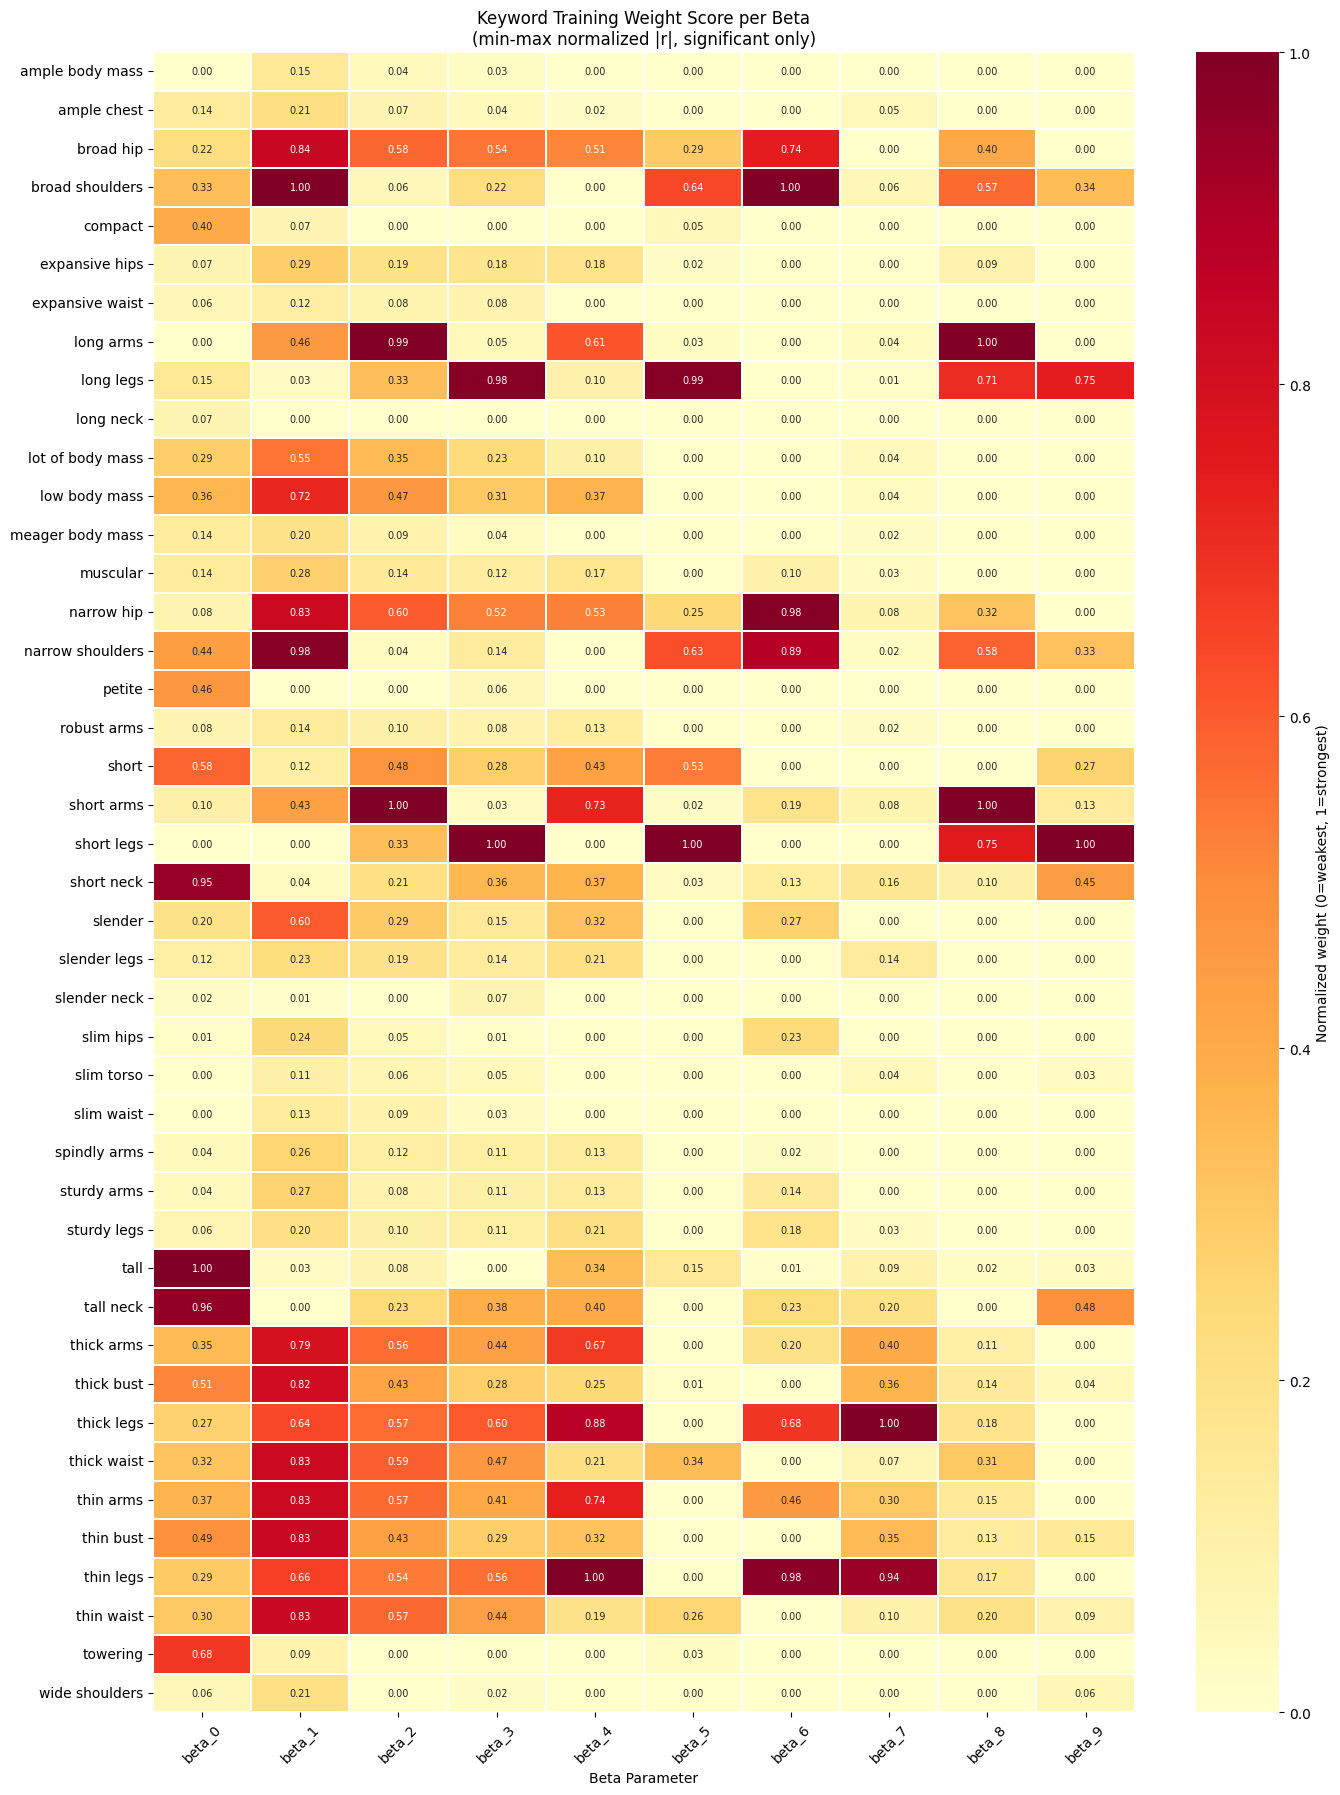

In [11]:
# Weight heatmap: keywords × betas (normalized weight, significant only)
weight_pivot = weight_df.pivot_table(
    index="keyword", columns="beta", values="weight", aggfunc="max"
)[ordered_cols].fillna(0)

fig, ax = plt.subplots(figsize=(14, max(6, len(weight_pivot) * 0.42)))
sns.heatmap(
    weight_pivot,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Normalized weight (0=weakest, 1=strongest)"},
)
ax.set_title("Keyword Training Weight Score per Beta\n(min-max normalized |r|, significant only)", fontsize=12)
ax.set_xlabel("Beta Parameter")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# ── Per-beta dominant keyword assignment ──────────────────────────────────────
# For each keyword, assign it to the beta where its weight is highest.
# This gives a "primary beta" per keyword — useful for constructing loss masks.

dominant = (
    weight_df
    .sort_values("weight", ascending=False)
    .drop_duplicates("keyword")   # keep best beta per keyword
    [["keyword", "beta", "r", "abs_r", "weight"]]
    .rename(columns={"beta": "primary_beta", "weight": "primary_weight"})
    .sort_values(["primary_beta", "primary_weight"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== Primary beta assignment per keyword ===")
dominant

=== Primary beta assignment per keyword ===


,keyword,primary_beta,r,abs_r,primary_weight
0,tall,beta_0,0.49349,0.49349,1.0000
1,tall neck,beta_0,0.47430,0.47430,0.9594
2,short neck,beta_0,-0.46997,0.46997,0.9502
3,towering,beta_0,0.34164,0.34164,0.6787
4,short,beta_0,-0.29448,0.29448,0.5790
5,petite,beta_0,-0.23900,0.23900,0.4616
6,compact,beta_0,-0.20750,0.20750,0.3950
7,long neck,beta_0,0.05528,0.05528,0.0729
8,broad shoulders,beta_1,0.43425,0.43425,1.0000
9,narrow shoulders,beta_1,-0.42766,0.42766,0.9842


## 8. Export Correlation Summary Table

Save results to CSV files for use during training configuration.

In [13]:
import os
OUT_DIR = os.path.dirname(os.path.abspath("body_shape_analysis.ipynb"))

# 1. Full correlation table
full_path = os.path.join(OUT_DIR, "keyword_beta_weights.csv")
corr_df.to_csv(full_path, index=False)
print(f"Saved full correlation table → {full_path}")

# 2. Pivot table  (keywords as rows, beta_0..beta_9 as columns)
pivot_path = os.path.join(OUT_DIR, "keyword_beta_pivot.csv")
r_pivot[ordered_cols].to_csv(pivot_path)
print(f"Saved pivot table            → {pivot_path}")

# 3. Normalized weight table
weight_path = os.path.join(OUT_DIR, "keyword_beta_weights_normalized.csv")
weight_pivot.to_csv(weight_path)
print(f"Saved normalized weights     → {weight_path}")

# 4. Primary-beta assignment (one row per keyword)
dominant_path = os.path.join(OUT_DIR, "keyword_primary_beta.csv")
dominant.to_csv(dominant_path, index=False)
print(f"Saved primary-beta table     → {dominant_path}")

# Preview normalized weight pivot
print()
weight_pivot.round(3)

Saved full correlation table → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_weights.csv
Saved pivot table            → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_pivot.csv
Saved normalized weights     → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_weights_normalized.csv
Saved primary-beta table     → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_primary_beta.csv



beta,beta_0,beta_1,beta_2,beta_3,beta_4,beta_5,beta_6,beta_7,beta_8,beta_9
keyword,,,,,,,,,,
ample body mass,0.000,0.153,0.045,0.026,0.000,0.000,0.000,0.000,0.000,0.000
ample chest,0.137,0.214,0.075,0.044,0.022,0.000,0.000,0.048,0.000,0.000
broad hip,0.223,0.840,0.577,0.544,0.514,0.293,0.744,0.001,0.404,0.000
broad shoulders,0.332,1.000,0.058,0.219,0.000,0.638,1.000,0.059,0.570,0.341
compact,0.395,0.075,0.002,0.000,0.000,0.051,0.000,0.000,0.000,0.000
expansive hips,0.072,0.289,0.191,0.179,0.181,0.018,0.000,0.000,0.086,0.000
expansive waist,0.062,0.121,0.081,0.082,0.000,0.000,0.000,0.000,0.000,0.000
long arms,0.000,0.459,0.992,0.048,0.613,0.027,0.000,0.036,1.000,0.000
long legs,0.154,0.034,0.334,0.985,0.097,0.985,0.000,0.014,0.706,0.746


---
## How to Use These Results for Training

| Output file | Purpose |
|---|---|
| `keyword_beta_weights.csv` | Full (keyword, beta, r, p, weight) table — use to filter or threshold |
| `keyword_beta_pivot.csv` | Raw Pearson r pivot — inspect sign and magnitude per cell |
| `keyword_beta_weights_normalized.csv` | Weight score 0→1 per (keyword, beta) — directly usable as loss weights |
| `keyword_primary_beta.csv` | Which single beta each keyword drives most — for regression target selection |

### Suggested training strategy

1. **Keyword → beta target mapping**: use `keyword_primary_beta.csv` to know which beta output node each input keyword should supervise.
2. **Per-sample loss weighting**: for a description containing keyword *k*, up-weight the MSE loss on `primary_beta` by `primary_weight` (0–1 score).
3. **Beta learnability check**: betas where no keyword reaches `weight ≥ 0.5` (e.g. beta_6) may need richer annotations or can be excluded from text-supervised loss.
4. **Sanity check signs**: `r > 0` means the keyword predicts *higher* beta values; `r < 0` means *lower* — ensure your model output convention matches.

---
## 9. Acceptable Beta Ranges per Keyword (One-to-Many Analysis)

The mapping from description → betas is **one-to-many**: a single keyword like `"tall"` is
compatible with many different body shapes. Instead of a single target value, each keyword
defines an **acceptable range** of betas.

**Method**: for every keyword, collect all `N_kw` samples that contain it, then compute
percentile intervals `[P10, P90]` and `[P25, P75]` for each beta. Samples whose betas
fall within these intervals are all "valid" targets for that keyword.

The **IQR band [P25, P75]** is the core acceptable range; `[P10, P90]` is the looser bound.


In [14]:

# ── Compute per-keyword beta statistics ────────────────────────────────────
PERCENTILES = [5, 10, 25, 50, 75, 90, 95]

range_records = []
for kw in kept_keywords:
    mask = presence_dict[kw].astype(bool)
    kw_betas = betas[mask]          # shape: (N_kw, 10)
    n = mask.sum()

    for b_idx in range(10):
        col = kw_betas[:, b_idx]
        pcts = np.percentile(col, PERCENTILES)
        row = {
            "keyword": kw,
            "beta": f"beta_{b_idx}",
            "beta_index": b_idx,
            "n_samples": int(n),
            "mean": round(col.mean(), 4),
            "std":  round(col.std(),  4),
        }
        for q, v in zip(PERCENTILES, pcts):
            row[f"p{q}"] = round(v, 4)
        # Acceptable range = IQR band [P25, P75]; loose = [P10, P90]
        row["range_lo"]  = row["p10"]
        row["range_hi"]  = row["p90"]
        row["iqr_lo"]    = row["p25"]
        row["iqr_hi"]    = row["p75"]
        row["iqr_width"] = round(row["iqr_hi"] - row["iqr_lo"], 4)
        range_records.append(row)

range_df = pd.DataFrame(range_records)
print(f"Range records: {len(range_df)}   ({len(kept_keywords)} keywords × 10 betas)")
range_df.head(20)


Range records: 440   (44 keywords × 10 betas)


,keyword,beta,beta_index,n_samples,mean,std,p5,p10,p25,p50,p75,p90,p95,range_lo,range_hi,iqr_lo,iqr_hi,iqr_width
0,tall,beta_0,0,4413,1.3374,1.0201,-0.4834,-0.0770,0.7470,1.3780,1.9780,2.5888,2.9878,-0.0770,2.5888,0.7470,1.9780,1.2310
1,tall,beta_1,1,4413,0.0890,1.5029,-2.4078,-1.8850,-0.9620,0.1420,1.1360,1.9944,2.5688,-1.8850,1.9944,-0.9620,1.1360,2.0980
2,tall,beta_2,2,4413,0.1238,1.4594,-2.3204,-1.7820,-0.8740,0.1200,1.1100,2.0282,2.5574,-1.7820,2.0282,-0.8740,1.1100,1.9840
3,tall,beta_3,3,4413,-0.0325,1.5365,-2.5108,-2.0188,-1.0810,-0.0380,1.0060,1.9706,2.5128,-2.0188,1.9706,-1.0810,1.0060,2.0870
4,tall,beta_4,4,4413,0.1196,1.4290,-2.2668,-1.7606,-0.8040,0.1260,1.0840,1.9238,2.4852,-1.7606,1.9238,-0.8040,1.0840,1.8880
5,tall,beta_5,5,4413,0.1066,1.4194,-2.2506,-1.7268,-0.8310,0.1000,1.0570,1.9486,2.4550,-1.7268,1.9486,-0.8310,1.0570,1.8880
6,tall,beta_6,6,4413,-0.0285,1.3880,-2.3382,-1.7892,-0.9240,-0.0200,0.9030,1.7308,2.2268,-1.7892,1.7308,-0.9240,0.9030,1.8270
7,tall,beta_7,7,4413,-0.0794,1.3789,-2.3540,-1.8370,-0.9990,-0.0900,0.8610,1.6990,2.2194,-1.8370,1.6990,-0.9990,0.8610,1.8600
8,tall,beta_8,8,4413,-0.0540,1.4002,-2.3312,-1.8846,-1.0000,-0.0390,0.8880,1.7260,2.2246,-1.8846,1.7260,-1.0000,0.8880,1.8880
9,tall,beta_9,9,4413,0.0523,1.4319,-2.3056,-1.8014,-0.9200,0.0410,1.0170,1.8908,2.4460,-1.8014,1.8908,-0.9200,1.0170,1.9370


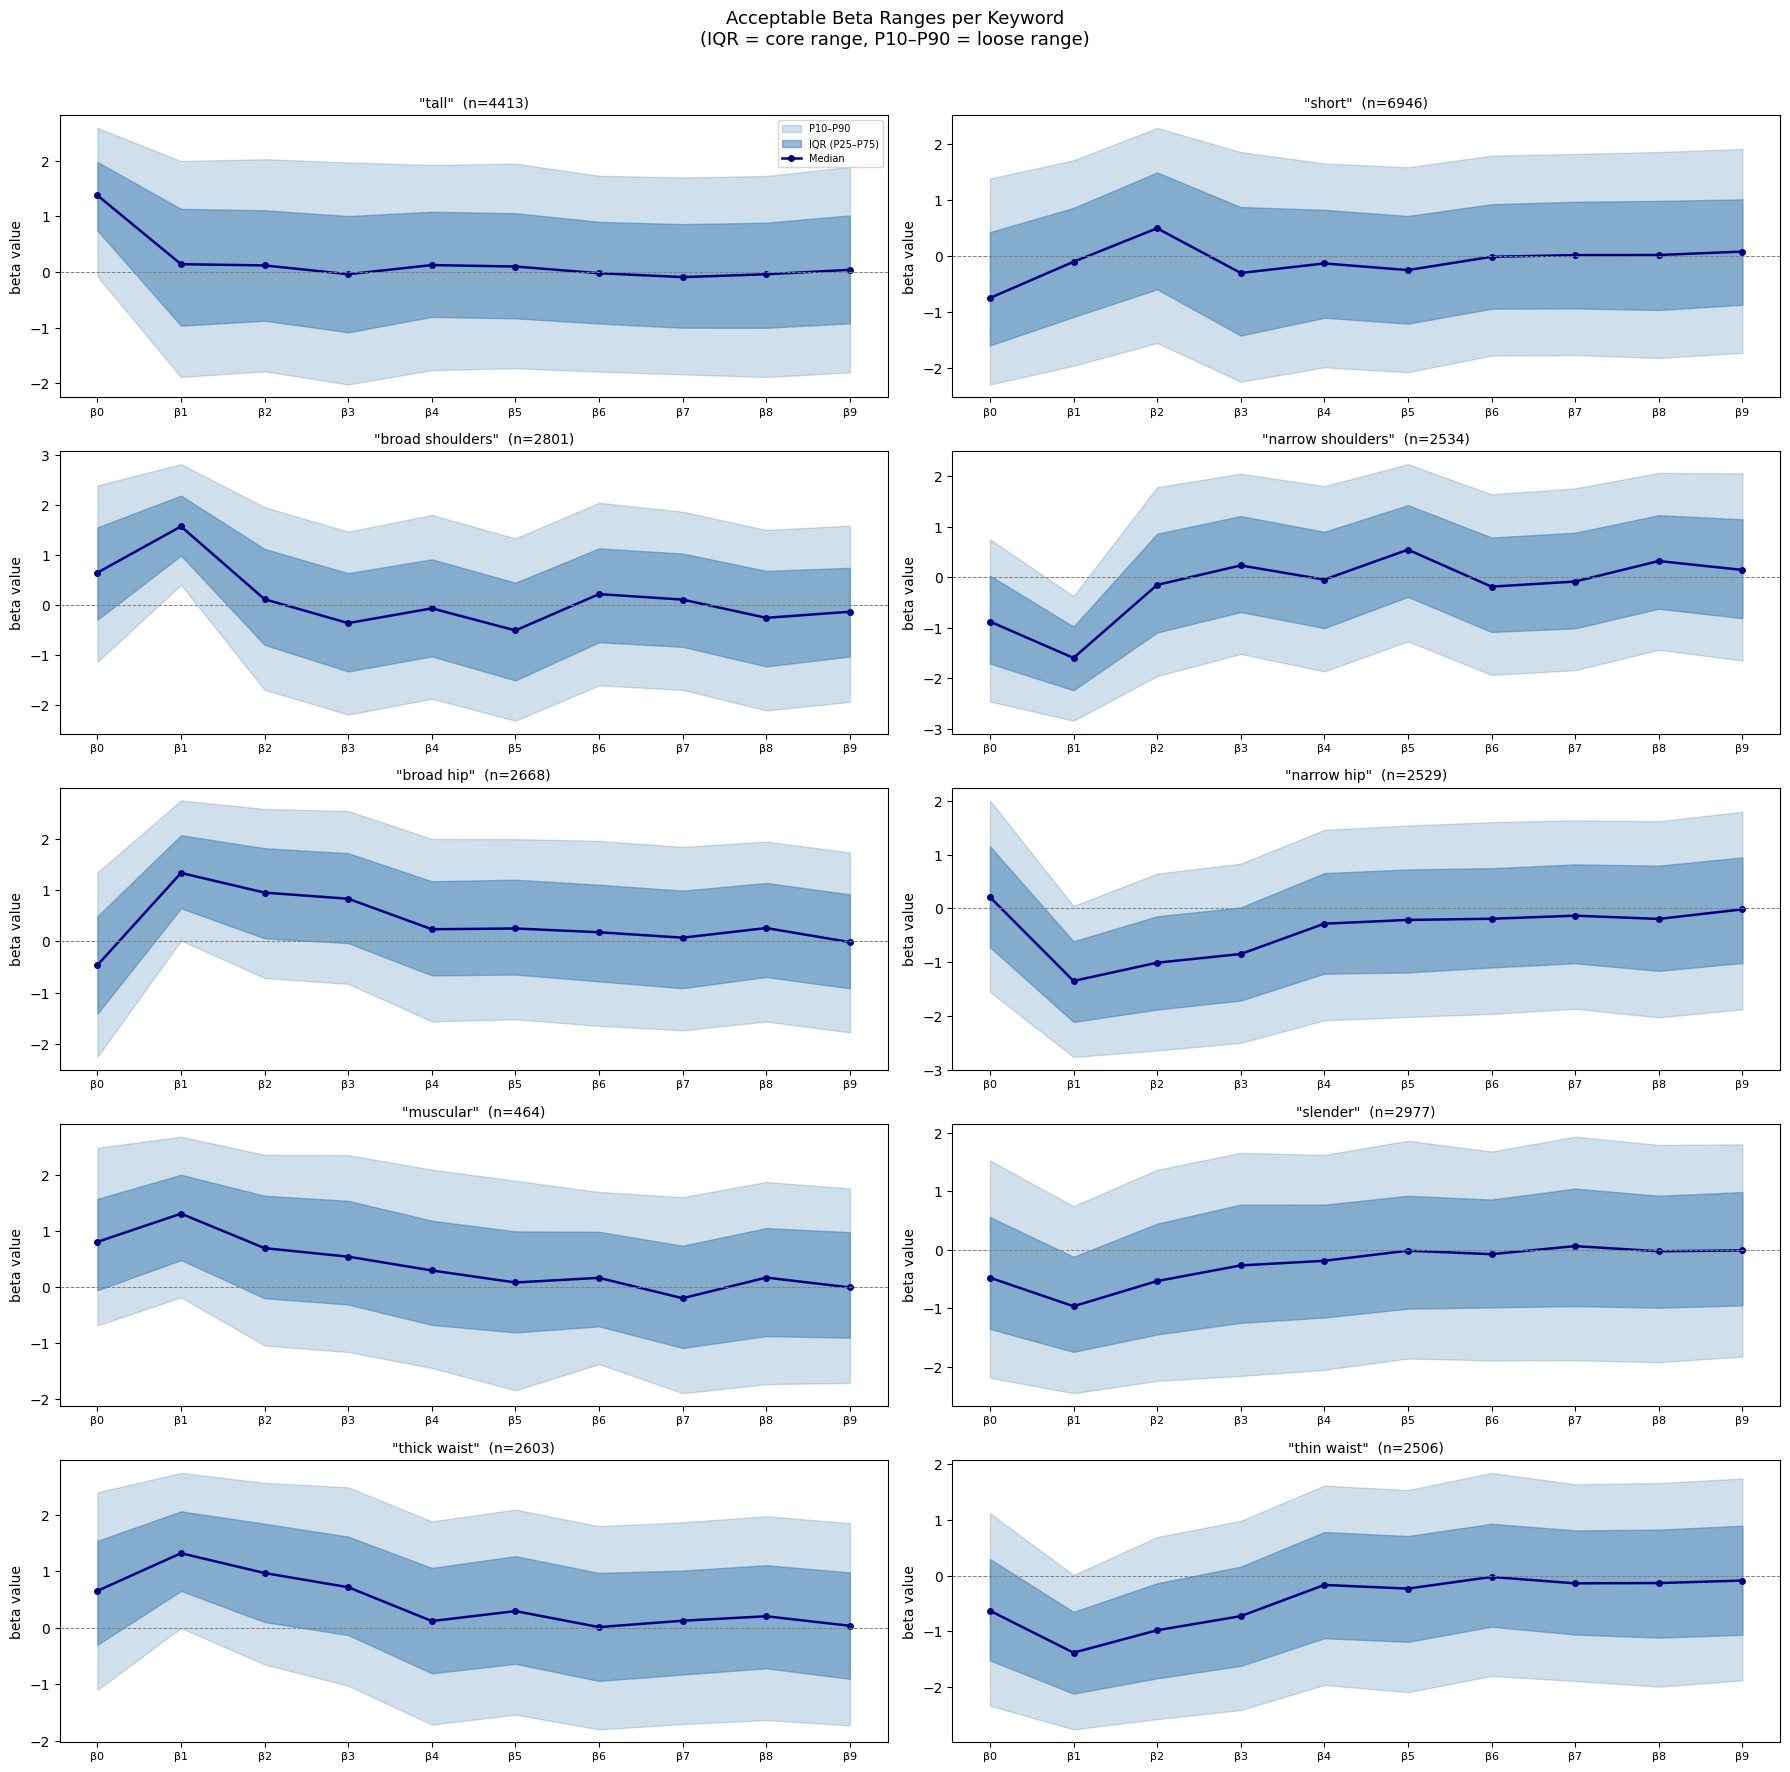

In [15]:

# ── Visualise: acceptable beta ranges for selected keywords ────────────────
# Shows the P10–P90 band (light) and P25–P75 IQR band (dark) per beta per keyword.

SHOW_KEYWORDS = [
    "tall", "short",
    "broad shoulders", "narrow shoulders",
    "broad hip", "narrow hip",
    "muscular", "slender",
    "thick waist", "thin waist",
]
# keep only those that survived the MIN_COUNT filter
SHOW_KEYWORDS = [kw for kw in SHOW_KEYWORDS if kw in kept_keywords]

n_kw = len(SHOW_KEYWORDS)
n_cols = 2
n_rows = (n_kw + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5), sharey=False)
axes = np.array(axes).flatten()

x = np.arange(10)
for ax_i, kw in enumerate(SHOW_KEYWORDS):
    ax = axes[ax_i]
    sub = range_df[range_df["keyword"] == kw].sort_values("beta_index")

    lo10 = sub["p10"].values;  hi10 = sub["p90"].values
    lo25 = sub["p25"].values;  hi75 = sub["p75"].values
    med  = sub["p50"].values

    # P10–P90 band
    ax.fill_between(x, lo10, hi10, alpha=0.25, color="steelblue", label="P10–P90")
    # IQR band
    ax.fill_between(x, lo25, hi75, alpha=0.55, color="steelblue", label="IQR (P25–P75)")
    # Median line
    ax.plot(x, med, color="navy", linewidth=1.8, marker="o", markersize=4, label="Median")
    # Zero reference
    ax.axhline(0, color="grey", linewidth=0.7, linestyle="--")

    n_s = int(sub["n_samples"].iloc[0])
    ax.set_title(f'"{kw}"  (n={n_s})', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"β{i}" for i in range(10)], fontsize=8)
    ax.set_ylabel("beta value")
    if ax_i == 0:
        ax.legend(fontsize=7, loc="upper right")

# hide unused axes
for ax_j in range(n_kw, len(axes)):
    axes[ax_j].set_visible(False)

plt.suptitle("Acceptable Beta Ranges per Keyword\n(IQR = core range, P10–P90 = loose range)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


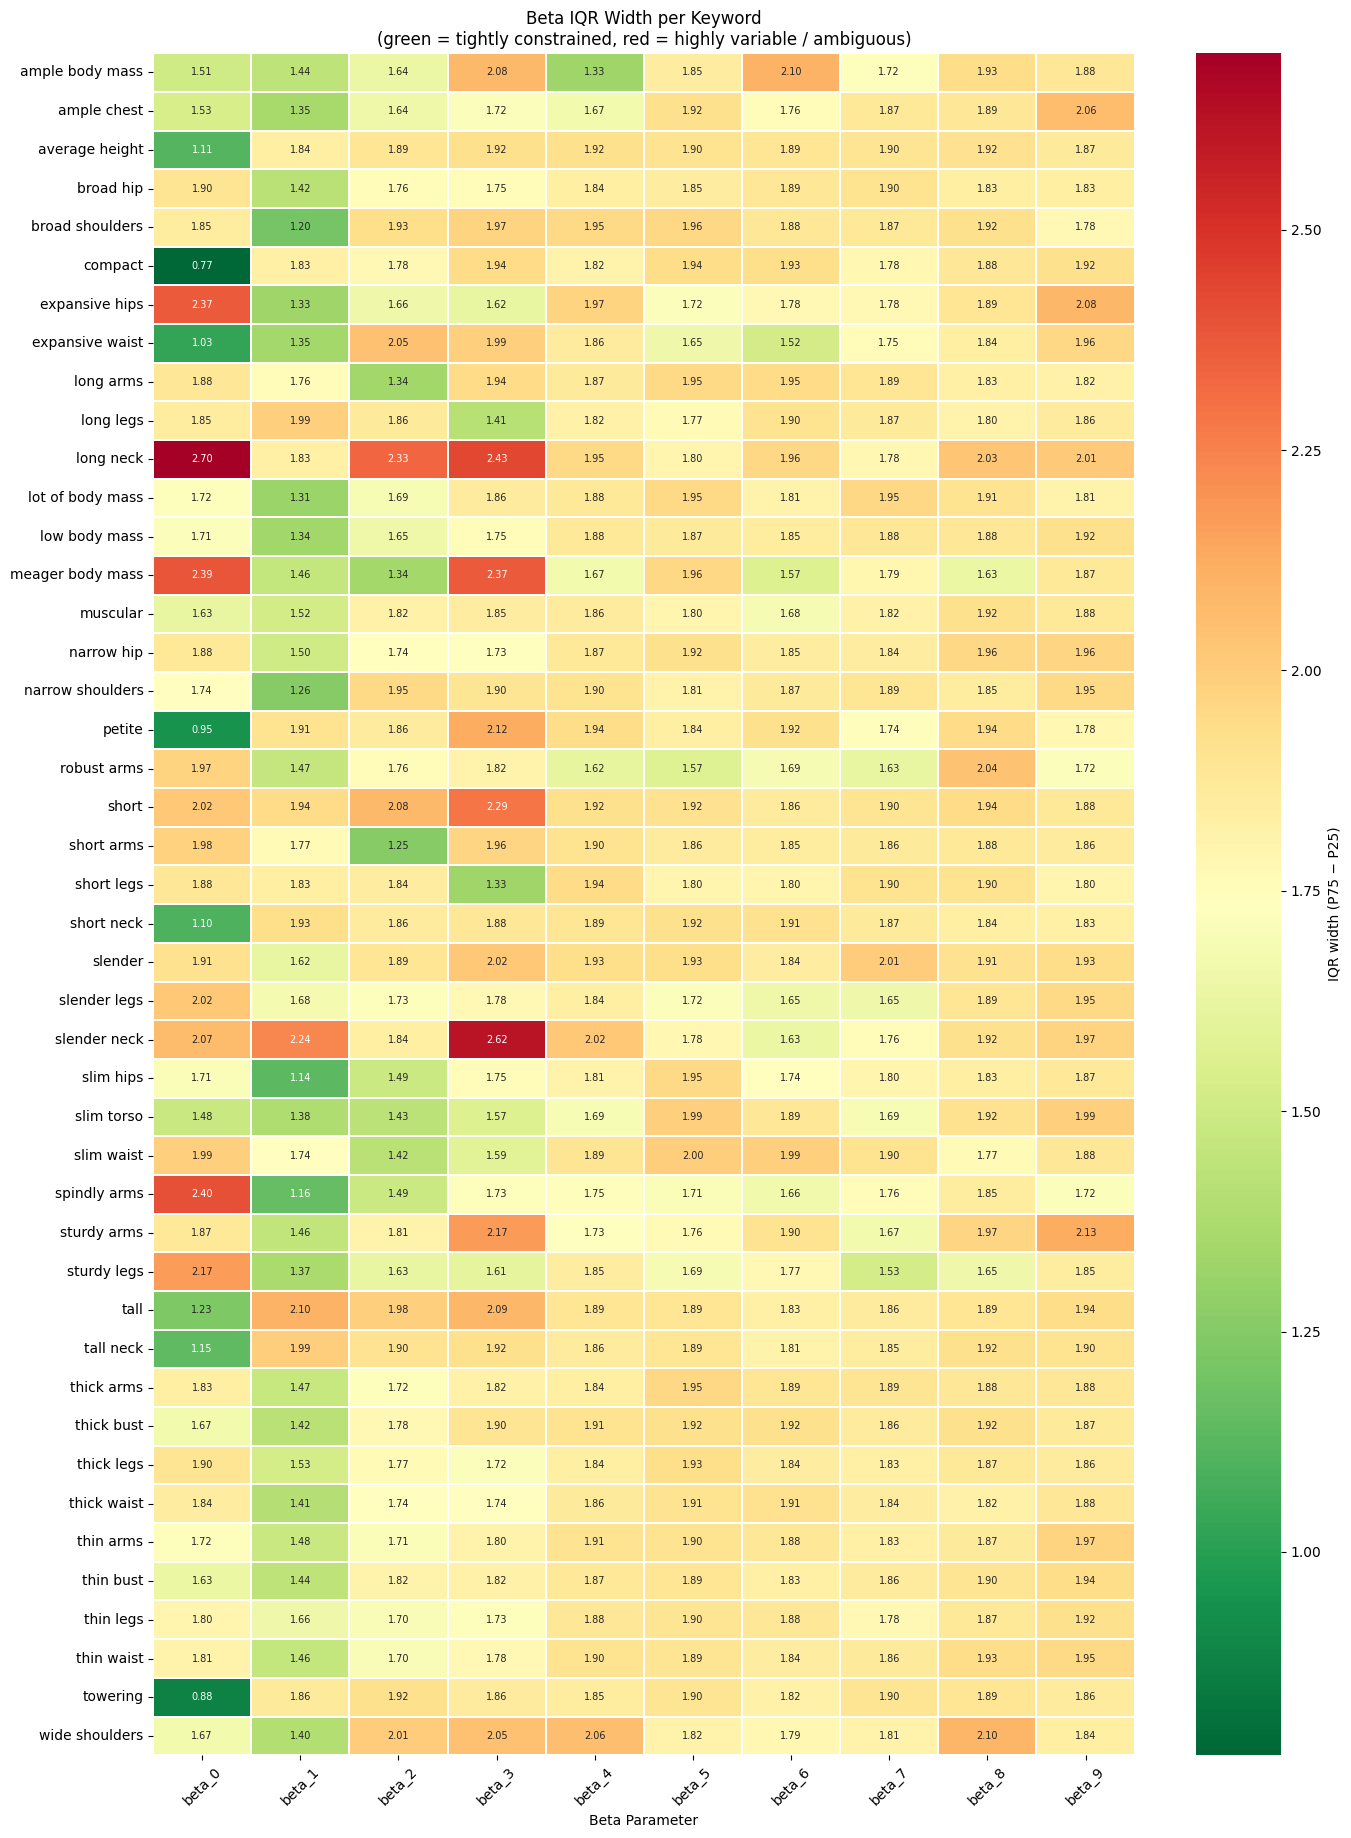

In [16]:

# ── Heatmap: IQR width per keyword × beta ─────────────────────────────────
# Wide IQR → that beta is loosely constrained by the keyword (high ambiguity).
# Narrow IQR → that beta is tightly constrained (strong cue).

iqr_pivot = range_df.pivot(index="keyword", columns="beta", values="iqr_width")[ordered_cols]

fig, ax = plt.subplots(figsize=(14, max(6, len(kept_keywords) * 0.42)))
sns.heatmap(
    iqr_pivot,
    cmap="RdYlGn_r",      # red = wide/ambiguous, green = tight/informative
    annot=True, fmt=".2f",
    annot_kws={"size": 7},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "IQR width (P75 − P25)"},
)
ax.set_title("Beta IQR Width per Keyword\n(green = tightly constrained, red = highly variable / ambiguous)", fontsize=12)
ax.set_xlabel("Beta Parameter")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [17]:

# ── Lookup helper: given any description, return acceptable beta ranges ─────

def get_beta_ranges(
    description: str,
    percentile_lo: float = 10,
    percentile_hi: float = 90,
    min_abs_r: float = 0.15,
) -> pd.DataFrame:
    """
    Given a free-text description, find all matching keywords and return
    the intersection / union of their acceptable beta ranges.

    For each beta the 'joint_lo' and 'joint_hi' are computed as:
      - joint_lo = max of individual lower bounds  (intersection → tighter)
      - joint_hi = min of individual upper bounds  (intersection → tighter)
    If no keyword matches, falls back to the global dataset range.
    """
    lo_col = f"p{int(percentile_lo)}"
    hi_col = f"p{int(percentile_hi)}"

    matched = [kw for kw in kept_keywords if kw.lower() in description.lower()]
    # Remove sub-phrase collisions: drop keyword A if another matched keyword B
    # contains A as a substring (e.g. "tall" dropped when "tall neck" also matched).
    matched = [kw for kw in matched
               if not any(kw != other and kw.lower() in other.lower()
                          for other in matched)]
    print(f"Description : '{description}'")
    print(f"Matched kws : {matched if matched else '(none — using global range)'}\n")

    # Load correlation strengths to filter weak-correlation keywords per beta
    corr_df = pd.read_csv(os.path.join(OUT_DIR, "keyword_beta_weights.csv"))

    rows = []
    for b_idx in range(10):
        beta = f"beta_{b_idx}"
        if matched:
            # Only constrain this beta using keywords that have |r| >= min_abs_r for it
            strong_kws = [
                kw for kw in matched
                if corr_df[(corr_df["keyword"] == kw) & (corr_df["beta"] == beta)]["abs_r"].values[0] >= min_abs_r
            ]
            if strong_kws:
                sub = range_df[(range_df["keyword"].isin(strong_kws)) & (range_df["beta"] == beta)]
                lo = sub[lo_col].max()
                hi = sub[hi_col].min()
                med = sub["p50"].mean()
            else:
                lo  = float(np.percentile(betas[:, b_idx], percentile_lo))
                hi  = float(np.percentile(betas[:, b_idx], percentile_hi))
                med = float(np.median(betas[:, b_idx]))
        else:
            # global range fallback
            lo  = float(np.percentile(betas[:, b_idx], percentile_lo))
            hi  = float(np.percentile(betas[:, b_idx], percentile_hi))
            med = float(np.median(betas[:, b_idx]))

        rows.append({
            "beta":     beta,
            "joint_lo": round(lo,  4),
            "median":   round(med, 4),
            "joint_hi": round(hi,  4),
            "width":    round(hi - lo, 4),
            "matched_keywords": ", ".join(matched) if matched else "—",
        })

    return pd.DataFrame(rows).set_index("beta")


# ── Demo ───────────────────────────────────────────────────────────────────
demo_descriptions = [
    "tall and broad shoulders",
    "short with narrow hip",
    "muscular with thick waist",
    "slender and long legs",
]

for desc in demo_descriptions:
    print("=" * 60)
    display(get_beta_ranges(desc))
    print()


Description : 'tall and broad shoulders'
Matched kws : ['tall', 'broad shoulders']



,joint_lo,median,joint_hi,width,matched_keywords
beta,,,,,
beta_0,-0.0770,1.0120,2.3980,2.4750,"tall, broad shoulders"
beta_1,0.4020,0.8580,1.9944,1.5924,"tall, broad shoulders"
beta_2,-1.7040,0.1165,1.9590,3.6630,"tall, broad shoulders"
beta_3,-2.0188,-0.2020,1.4700,3.4888,"tall, broad shoulders"
beta_4,-1.7606,0.0280,1.8050,3.5656,"tall, broad shoulders"
beta_5,-1.7268,-0.2065,1.3330,3.0598,"tall, broad shoulders"
beta_6,-1.6150,0.0980,1.7308,3.3458,"tall, broad shoulders"
beta_7,-1.7060,0.0080,1.6990,3.4050,"tall, broad shoulders"
beta_8,-1.8846,-0.1495,1.5030,3.3876,"tall, broad shoulders"



Description : 'short with narrow hip'
Matched kws : ['short', 'narrow hip']



,joint_lo,median,joint_hi,width,matched_keywords
beta,,,,,
beta_0,-1.5530,-0.2690,1.3765,2.9295,"short, narrow hip"
beta_1,-1.9550,-0.7275,0.0450,2.0000,"short, narrow hip"
beta_2,-1.5495,-0.2595,0.6464,2.1959,"short, narrow hip"
beta_3,-2.2385,-0.5762,0.8322,3.0707,"short, narrow hip"
beta_4,-1.9825,-0.2095,1.4616,3.4441,"short, narrow hip"
beta_5,-2.0202,-0.2335,1.5424,3.5626,"short, narrow hip"
beta_6,-1.7735,-0.1042,1.6046,3.3781,"short, narrow hip"
beta_7,-1.7660,-0.0608,1.6386,3.4046,"short, narrow hip"
beta_8,-1.8165,-0.0900,1.6216,3.4381,"short, narrow hip"



Description : 'muscular with thick waist'
Matched kws : ['muscular', 'thick waist']



,joint_lo,median,joint_hi,width,matched_keywords
beta,,,,,
beta_0,-0.6847,0.7290,2.4004,3.0851,"muscular, thick waist"
beta_1,-0.0032,1.3135,2.6757,2.6789,"muscular, thick waist"
beta_2,-0.6470,0.8310,2.3528,2.9998,"muscular, thick waist"
beta_3,-1.0246,0.6298,2.3477,3.3723,"muscular, thick waist"
beta_4,-1.4426,0.2072,1.8860,3.3286,"muscular, thick waist"
beta_5,-1.5350,0.1882,1.8918,3.4268,"muscular, thick waist"
beta_6,-1.3741,0.0880,1.6911,3.0652,"muscular, thick waist"
beta_7,-1.7038,-0.0370,1.6000,3.3038,"muscular, thick waist"
beta_8,-1.6318,0.1865,1.8689,3.5007,"muscular, thick waist"



Description : 'slender and long legs'
Matched kws : ['long legs', 'slender']



,joint_lo,median,joint_hi,width,matched_keywords
beta,,,,,
beta_0,-2.0909,-0.4112,1.4260,3.5169,"long legs, slender"
beta_1,-1.7791,-0.4010,0.7460,2.5251,"long legs, slender"
beta_2,-2.2374,-0.5558,1.2467,3.4841,"long legs, slender"
beta_3,0.1701,0.6270,1.6552,1.4851,"long legs, slender"
beta_4,-1.8826,-0.1432,1.6214,3.5040,"long legs, slender"
beta_5,-0.9630,0.3860,1.8622,2.8252,"long legs, slender"
beta_6,-1.7479,-0.0410,1.6786,3.4265,"long legs, slender"
beta_7,-1.7066,0.0510,1.8586,3.5652,"long legs, slender"
beta_8,-1.9190,-0.1910,1.4035,3.3225,"long legs, slender"


In [18]:

# ── Export beta range table ─────────────────────────────────────────────────
range_path = os.path.join(OUT_DIR, "keyword_beta_ranges.csv")
range_df.to_csv(range_path, index=False)
print(f"Saved beta range table → {range_path}")
print("\nColumns: keyword, beta, n_samples, mean, std, p5..p95, range_lo/hi (P10–P90), iqr_lo/hi (P25–P75), iqr_width")
range_df[range_df["keyword"] == "tall"][["keyword","beta","n_samples","mean","std","iqr_lo","iqr_hi","range_lo","range_hi"]].reset_index(drop=True)


Saved beta range table → /home/schaeffler-pte-ltd/david_ws/BodyShapeGPT/scripts/keyword_beta_ranges.csv

Columns: keyword, beta, n_samples, mean, std, p5..p95, range_lo/hi (P10–P90), iqr_lo/hi (P25–P75), iqr_width


,keyword,beta,n_samples,mean,std,iqr_lo,iqr_hi,range_lo,range_hi
0,tall,beta_0,4413,1.3374,1.0201,0.747,1.978,-0.0770,2.5888
1,tall,beta_1,4413,0.0890,1.5029,-0.962,1.136,-1.8850,1.9944
2,tall,beta_2,4413,0.1238,1.4594,-0.874,1.110,-1.7820,2.0282
3,tall,beta_3,4413,-0.0325,1.5365,-1.081,1.006,-2.0188,1.9706
4,tall,beta_4,4413,0.1196,1.4290,-0.804,1.084,-1.7606,1.9238
5,tall,beta_5,4413,0.1066,1.4194,-0.831,1.057,-1.7268,1.9486
6,tall,beta_6,4413,-0.0285,1.3880,-0.924,0.903,-1.7892,1.7308
7,tall,beta_7,4413,-0.0794,1.3789,-0.999,0.861,-1.8370,1.6990
8,tall,beta_8,4413,-0.0540,1.4002,-1.000,0.888,-1.8846,1.7260
9,tall,beta_9,4413,0.0523,1.4319,-0.920,1.017,-1.8014,1.8908
